# Customer Segmentation
This notebook assigns business-facing segments, evaluates revenue concentration, flags churn risk, and summarizes recommendations.

## Suggested Actions
- **Champions**: Reward with VIP perks, early product access, and referral campaigns to amplify advocacy.\n- **Loyal Customers**: Deepen retention using bundles, subscription offers, and personalized cross-sell messaging.\n- **Potential Loyalists**: Nudge toward a second or third order with limited-time offers and product education.\n- **New Customers**: Improve onboarding with welcome journeys, category discovery, and first-repeat discounts.\n- **Big Spenders**: Protect high-value shoppers with concierge-style support and premium assortment recommendations.\n- **At Risk**: Trigger win-back campaigns using urgency, replenishment reminders, and service outreach.\n- **Hibernating**: Use low-cost reactivation channels and suppress expensive paid media unless engagement returns.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
from src.rfm import detect_churn_risk, segment_revenue_contribution, segment_churn_summary
from src.segmentation import assign_segments, get_business_recommendations

clean_path = ROOT / 'data' / 'cleaned' / 'ecommerce_transactions_cleaned.csv'
scores_path = ROOT / 'data' / 'cleaned' / 'customer_rfm_scores.csv'
segments_path = ROOT / 'data' / 'cleaned' / 'customer_rfm_segments.csv'
df = pd.read_csv(clean_path, parse_dates=['Order Date'])
rfm = pd.read_csv(scores_path, parse_dates=['Last_Order_Date'])
if 'Segment' not in rfm.columns:
    rfm = assign_segments(rfm)
rfm = detect_churn_risk(rfm)
rfm.to_csv(segments_path, index=False)
rfm.head()

,Customer ID,Recency,Frequency,Monetary,Last_Order_Date,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Segment,Churn Risk
0,CUST-0424,24,18,3908.47,2024-12-08,4,4,4,444,12,Champions,Low Risk
1,CUST-0390,41,16,2879.98,2024-11-21,4,4,4,444,12,Champions,Low Risk
2,CUST-0069,16,18,2860.53,2024-12-16,4,4,4,444,12,Champions,Low Risk
3,CUST-0826,24,16,2701.81,2024-12-08,4,4,4,444,12,Champions,Low Risk
4,CUST-0659,27,16,2675.58,2024-12-05,4,4,4,444,12,Champions,Low Risk


In [2]:
segment_summary = segment_revenue_contribution(rfm)
segment_summary

,Segment,Customers,Revenue,Avg_Customer_Value,Revenue Share %
0,Loyal Customers,182,188486.64,1035.640879,35.451942
1,Champions,68,103997.83,1529.379853,19.560671
2,At Risk,101,90764.61,898.659505,17.071670
3,Hibernating,250,59118.22,236.472880,11.119386
4,Potential Loyalists,140,56907.57,406.482643,10.703591
5,New Customers,57,22146.63,388.537368,4.165500
6,Big Spenders,9,10246.52,1138.502222,1.927240


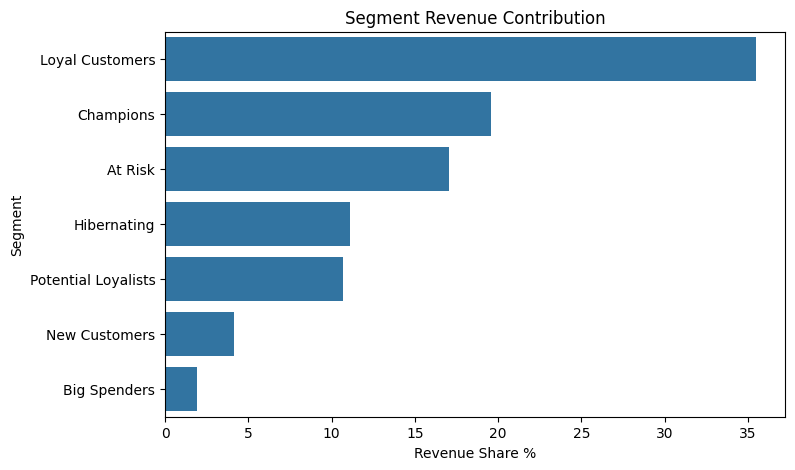

In [3]:
plt.figure(figsize=(8, 5))
sns.barplot(data=segment_summary, x='Revenue Share %', y='Segment')
plt.title('Segment Revenue Contribution')
plt.show()

In [4]:
churn_summary = segment_churn_summary(rfm)
churn_summary

,Segment,Churn Risk,Customers,Revenue
0,At Risk,Medium Risk,101,90764.61
1,Big Spenders,Low Risk,5,5504.47
2,Big Spenders,Medium Risk,4,4742.05
3,Champions,Low Risk,68,103997.83
5,Hibernating,Medium Risk,129,35313.07
4,Hibernating,High Risk,121,23805.15
6,Loyal Customers,Low Risk,181,187528.60
7,Loyal Customers,Medium Risk,1,958.04
8,New Customers,Low Risk,57,22146.63
10,Potential Loyalists,Low Risk,91,30943.56


## KPI Snapshot
- Transactions analyzed: **3,597**
- Customers analyzed: **807**
- Revenue analyzed: **$531,668.02**
- Average order value: **$147.81**
- Repeat purchase rate: **86.0%**